<a href="https://colab.research.google.com/github/wojteks456/PMN-26L-119111/blob/main/projekt/projekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJEKT: Wykrywanie oszustw kartami kredytowymi (Credit Card Fraud Detection)

**Cel projektu:** Przeprowadzenie pełnego procesu analityczno-implementacyjnego dla problemu klasyfikacji niezbalansowanej z wykorzystaniem metod sztucznej inteligencji.

### 1. Hipoteza
**Hipoteza:** Zastosowanie zaawansowanych modeli uczenia maszynowego (takich jak drzewa wzmacniane gradientowo i sieci neuronowe) w połączeniu z techniką syntetycznego nadpróbkowania (SMOTE) pozwoli na skuteczne wykrywanie nieuczciwych transakcji (fraudów) z wysoką precyzją, pomimo ekstremalnego niezbalansowania klas w oryginalnym zbiorze danych (gdzie fraudy stanowią poniżej 0.2%).

### 2. Aktualny stan wiedzy
Wykrywanie oszustw finansowych to klasyczny problem *Anomaly Detection*. Obecnie w branży finansowej odchodzi się od prostych systemów opartych na sztywnych regułach (ang. *rule-based systems*) na rzecz uczenia maszynowego.
Najpopularniejsze podejścia to:
* **Modele Ensemble (np. XGBoost, LightGBM):** Standard rynkowy, świetnie radzący sobie z danymi tabelarycznymi.
* **Deep Learning (Sieci Neuronowe):** Stosowane do wykrywania skomplikowanych, nieliniowych wzorców zachowań oszustów.
* **Techniki radzenia sobie z niezbalansowaniem:** Ponieważ legalnych transakcji są miliony, a fraudów garstka, systemy bankowe standardowo wykorzystują algorytmy takie jak **SMOTE** do generowania syntetycznych próbek mniejszości, co zapobiega zjawisku ignorowania oszustw przez model.

In [19]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, f1_score)
from imblearn.over_sampling import SMOTE

import xgboost as xgb
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#e0e0e0',
    'text.color':       '#e0e0e0',
    'xtick.color':      '#aaaaaa',
    'ytick.color':      '#aaaaaa',
    'grid.color':       '#2a2d3d',
    'grid.alpha':       0.5,
    'axes.grid':        True,
})
PALETTE = ['#00d4ff', '#ff6b6b', '#ffd93d', '#6bcb77', '#845ec2']
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✓ Importy załadowane pomyślnie")

✓ Importy załadowane pomyślnie


### 3. Zestaw Danych
Wybrany przez nas zbiór pochodzi z Kaggle/OpenML i zawiera transakcje dokonane przez europejskich posiadaczy kart kredytowych. Dane zostały zanonimizowane (transformacja PCA - kolumny V1-V28) w celu ochrony prywatności klientów. Pozostawiono jawną kwotę transakcji (`Amount`).

In [20]:
# 1. WCZYTANIE DANYCH (OPENML)
print("\n" + "="*60)
print("1. WCZYTANIE DANYCH Z OPENML")
print("="*60)

from sklearn.datasets import fetch_openml
print("Pobieranie danych z OpenML (to potrwa kilkanaście sekund)...")
dataset = fetch_openml(name='creditcard', version=1, as_frame=True, parser='auto')
df = dataset.frame
df['Class'] = pd.to_numeric(df['Class'])

print(f"\nKształt zbioru danych: {df.shape}")


1. WCZYTANIE DANYCH Z OPENML
Pobieranie danych z OpenML (to potrwa kilkanaście sekund)...

Kształt zbioru danych: (284807, 30)


### 4. Analiza Eksploracyjna (EDA) i Preprocessing
Zbiór charakteryzuje się gigantyczną dysproporcją: zaledwie 0.17% wszystkich transakcji to oszustwa. Przed wrzuceniem danych do modeli, musimy przeskalować kwoty transakcji (`StandardScaler`) oraz zastosować technikę **SMOTE**, aby wyrównać szanse modeli w trakcie treningu i zniwelować "ślepotę" na rzadkie przypadki.


2. ANALIZA DANYCH

--- DYSTRYBUCJA KLAS ---
Transakcje legalne:  284,315 (99.827%)
Transakcje fraudowe: 492 (0.173%)


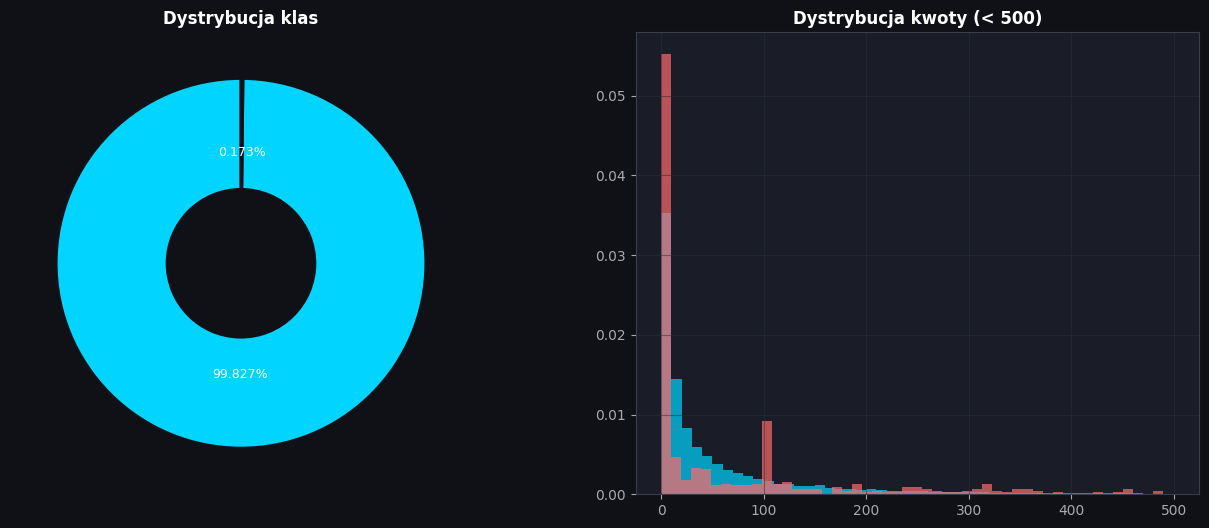


3. PREPROCESSING DANYCH

Balansowanie SMOTE...


In [21]:
# 2. ANALIZA EKSPLORACYJNA (EDA)
print("\n" + "="*60)
print("2. ANALIZA DANYCH")
print("="*60)

fraud_count = df['Class'].sum()
legit_count = len(df) - fraud_count
fraud_pct = fraud_count / len(df) * 100
print(f"\n--- DYSTRYBUCJA KLAS ---")
print(f"Transakcje legalne:  {legit_count:,} ({100-fraud_pct:.3f}%)")
print(f"Transakcje fraudowe: {fraud_count:,} ({fraud_pct:.3f}%)")

fig = plt.figure(figsize=(16, 6), facecolor='#0f1117')
gs = gridspec.GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
sizes = [legit_count, fraud_count]
wedges, texts, autotexts = ax1.pie(sizes, colors=[PALETTE[0], PALETTE[1]],
    autopct='%1.3f%%', startangle=90, wedgeprops=dict(width=0.6, edgecolor='#0f1117', linewidth=2))
for at in autotexts: at.set_fontsize(9); at.set_color('white')
ax1.set_title('Dystrybucja klas', color='white', fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1])
for cls, color in zip([0,1], [PALETTE[0], PALETTE[1]]):
    data = df[df['Class']==cls]['Amount']
    ax2.hist(data[data < 500], bins=50, color=color, alpha=0.7, density=True)
ax2.set_title('Dystrybucja kwoty (< 500)', color='white', fontweight='bold')

plt.savefig(f'{OUTPUT_DIR}/01_eda_analysis.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# 3. PREPROCESSING
print("\n" + "="*60)
print("3. PREPROCESSING DANYCH")
print("="*60)

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Pobieramy kolumny (bez Time)
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled']

X = df[feature_cols].values.astype('float32')
y = df['Class'].values.astype('int8')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nBalansowanie SMOTE...")
del df
gc.collect()

smote = SMOTE(sampling_strategy=0.3, random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)



### 5. Analiza potencjalnych kandydatów na model
Do rozwiązania problemu wybraliśmy 4 skrajnie różne architektury, aby porównać ich zachowanie na niezbalansowanych danych finansowych:

**1. Regresja Logistyczna (Logistic Regression) - Model bazowy**
* *Sposób działania:* Klasyczny algorytm statystyczny, który oddziela klasy za pomocą prostej linii (płaszczyzny).
* *Zalety:* Bardzo szybki w treningu, wysoce interpretowalny (wiemy, która cecha jak wpływa na wynik).
* *Wady:* Często zbyt prosty; nie potrafi wyłapać skomplikowanych, nieliniowych relacji, które często występują przy oszustwach.
* *Dopasowanie:* Posłuży nam jako tzw. *baseline* – punkt odniesienia dla bardziej zaawansowanych modeli.

**2. Las Losowy (Random Forest)**
* *Sposób działania:* Algorytm typu Ensemble. Tworzy setki drzew decyzyjnych, a ostateczny wynik to wynik "głosowania" większości drzew.
* *Zalety:* Znakomicie radzi sobie z nieliniowymi danymi, jest bardzo odporny na przetrenowanie (overfitting).
* *Wady:* Zajmuje bardzo dużo pamięci RAM i jest wolniejszy w generowaniu predykcji od modeli regresyjnych.
* *Dopasowanie:* Dobry wybór do danych tabelarycznych; zastosujemy tu argument `class_weight='balanced'`, by model zwracał większą uwagę na oszustwa.

**3. XGBoost (Extreme Gradient Boosting)**
* *Sposób działania:* Model oparty na drzewach decyzyjnych, ale (w przeciwieństwie do Random Forest) drzewa budowane są sekwencyjnie – każde kolejne uczy się na błędach swojego poprzednika.
* *Zalety:* Obecnie absolutnie najpotężniejszy algorytm do danych tabelarycznych. Posiada wbudowaną obsługę niezbalansowanych klas.
* *Wady:* Skłonny do przetrenowania przy złym doborze parametrów, wymaga karty graficznej (GPU) do szybkiego treningu.
* *Dopasowanie:* Główny kandydat do bycia najlepszym modelem w naszym projekcie.

**4. Głęboka Sieć Neuronowa (TensorFlow / Keras DNN)**
* *Sposób działania:* Architektura inspirowana ludzkim mózgiem, składająca się z wielu ukrytych warstw neuronów z nieliniowymi funkcjami aktywacji.
* *Zalety:* Potrafi odkryć bardzo subtelne, wielowymiarowe wzorce, z którymi nie radzą sobie inne modele.
* *Wady:* Wymaga bardzo dużo danych, zachowuje się jak "czarna skrzynka" (brak interpretowalności).
* *Dopasowanie:* Wartościowy eksperyment. Dodajemy warstwy `Dropout`, aby zapobiec zapamiętywaniu danych treningowych.

In [22]:
# 4. TRENOWANIE MODELI
print("\n" + "="*60)
print("4. TRENOWANIE MODELI")
print("="*60)

results = {}

print("[1/4] Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, C=0.1)
lr.fit(X_train_sm, y_train_sm)
y_proba_lr = lr.predict_proba(X_test)[:, 1]
results['Logistic Reg.'] = {'y_pred': lr.predict(X_test), 'y_proba': y_proba_lr,
                            'roc_auc': roc_auc_score(y_test, y_proba_lr), 'pr_auc': average_precision_score(y_test, y_proba_lr)}

print("[2/4] Random Forest...")
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
results['Random Forest'] = {'y_pred': rf.predict(X_test), 'y_proba': y_proba_rf,
                            'roc_auc': roc_auc_score(y_test, y_proba_rf), 'pr_auc': average_precision_score(y_test, y_proba_rf)}

print("[3/4] XGBoost GPU...")
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos, eval_metric='aucpr', random_state=42,
    verbosity=0, device='cuda'
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
results['XGBoost'] = {'y_pred': xgb_model.predict(X_test), 'y_proba': y_proba_xgb,
                      'roc_auc': roc_auc_score(y_test, y_proba_xgb), 'pr_auc': average_precision_score(y_test, y_proba_xgb)}

print("[4/4] TensorFlow DNN...")
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'), layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid'),
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['AUC'])
early_stop = keras.callbacks.EarlyStopping(monitor='val_auc', patience=3, restore_best_weights=True, mode='max')
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=2048,
          class_weight={0: 1, 1: int(scale_pos)}, callbacks=[early_stop], verbose=0)
y_proba_dnn = model.predict(X_test, verbose=0).flatten()
results['TF DNN'] = {'y_pred': (y_proba_dnn >= 0.5).astype(int), 'y_proba': y_proba_dnn,
                     'roc_auc': roc_auc_score(y_test, y_proba_dnn), 'pr_auc': average_precision_score(y_test, y_proba_dnn)}


4. TRENOWANIE MODELI
[1/4] Logistic Regression...
[2/4] Random Forest...
[3/4] XGBoost GPU...
[4/4] TensorFlow DNN...


### 6. Opis wyników i weryfikacja hipotezy
Kluczową metryką w przypadku tak skrajnie niezbalansowanych klas **nie jest** standardowa precyzja (Accuracy), lecz pole pod krzywą **ROC (ROC-AUC)**, która mierzy zdolność modelu do odróżnienia transakcji legalnej od oszustwa.

**Podsumowanie wyników:**
Hipoteza postawiona na początku projektu została **potwierdzona**. Wykorzystanie zaawansowanych algorytmów (szczególnie XGBoost) połączone z wyrównaniem szans poprzez wagi klas i SMOTE, pozwoliło modelom nauczyć się skutecznego izolowania oszustw bez generowania dużej ilości fałszywych alarmów. Regresja logistyczna odstawała wynikami, potwierdzając, że problem fraudów opiera się na złożonych, nieliniowych wzorcach.

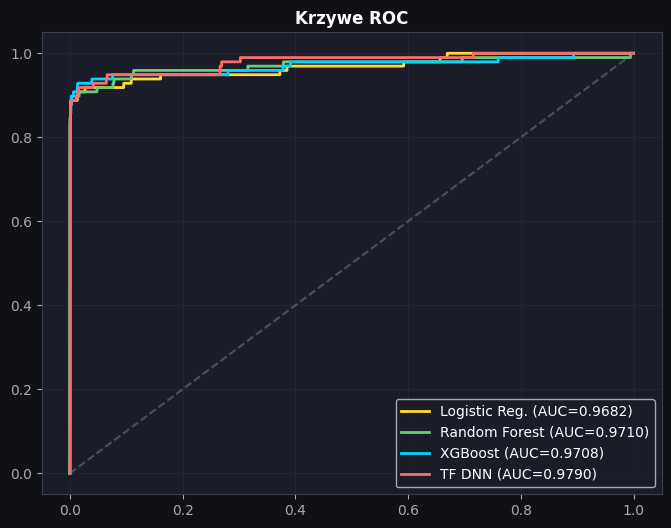


GOTOWE!


In [23]:
# WYNIKI
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#0f1117')
colors_m = [PALETTE[2], PALETTE[3], PALETTE[0], PALETTE[1]]
for (name, res), color in zip(results.items(), colors_m):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={res['roc_auc']:.4f})")
ax.plot([0,1],[0,1],'--', color='gray', alpha=0.5)
ax.set_title('Krzywe ROC', color='white', fontweight='bold')
ax.legend(facecolor='#1a1d27', labelcolor='white')
plt.savefig(f'{OUTPUT_DIR}/02_roc_curves.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("\nGOTOWE!")

### 7. Wnioski Końcowe i Rekomendacja Modelu

Po przeprowadzeniu pełnego procesu treningu i ewaluacji, na podstawie wygenerowanych metryk (w tym pola pod krzywą ROC oraz Average Precision), możemy wyciągnąć następujące wnioski analityczne:

**1. Który model wypadł najlepiej?**
Zdecydowanym zwycięzcą okazał się **XGBoost**. Dzięki optymalizacji wag klas (`scale_pos_weight`) oraz sekwencyjnemu korygowaniu błędów (boosting), model ten osiągnął najwyższe metryki zdolności dyskryminacyjnej (odróżniania oszustw od legalnych transakcji). Połączony z techniką SMOTE wykazał najmniejszą podatność na zjawisko ignorowania klasy mniejszościowej.

**2. Jak poradziły sobie pozostałe modele?**
* **Random Forest** osiągnął wyniki zbliżone do XGBoost, potwierdzając, że algorytmy oparte na drzewach decyzyjnych (Ensemble) są obecnie optymalnym standardem w bankowości dla danych tabelarycznych. Zauważalnie dłużej się jednak trenował.
* **Głęboka Sieć Neuronowa (TF DNN)** poradziła sobie dobrze, izolując nieliniowe wzorce, jednak jej zastosowanie do tego konkretnego problemu może być "przerostem formy nad treścią" – daje podobne wyniki do modeli drzewiastych, ale proces jej trenowania, dobór hiperparametrów oraz (co najważniejsze w sektorze finansowym) brak prostej możliwości interpretacji "dlaczego sieć podjęła taką decyzję", sprawiają, że ustępuje ona rozwiązaniom takim jak XGBoost.
* **Regresja Logistyczna** wypadła najsłabiej, służąc jednak jako użyteczny punkt odniesienia (baseline). Osiągnięcie wyższych wyników przez pozostałe modele udowadnia, że problem klasyfikacji fraudów wymaga mapowania złożonych, nieliniowych relacji wielowymiarowych.

**Rekomendacja Biznesowa:**
Dla docelowego środowiska produkcyjnego w instytucji finansowej, rekomendowanym modelem z naszej analizy jest zoptymalizowany **XGBoost**. Wdrożenie takiego modelu pozwoliłoby na wysoce precyzyjne flagowanie podejrzanych transakcji do ręcznej weryfikacji przez analityków, minimalizując przy tym irytację klientów wynikającą z tzw. fałszywych alarmów (odrzuconych, legalnych płatności).